# MNIST (Modified National Institute of Standards and Technology)

O que é o MNIST?

* O conteúdo: 70.000 imagens em escala de cinza de dígitos manuscritos (números de 0 a 9).
* Dimensões de cada imagem: $28 \times 28$ pixels.
* Valores dos pixels: Números inteiros de 0 a 255, onde $0$ é o fundo preto (ou branco, dependendo da escala) e $255$ é o traço mais forte da caneta.

O ML Clássico:

* Modelos clássicos (como SVM, KNN, Random Forest ou Regressão Logística) não entendem matrizes 2D de imagem.
* Por isso, cada imagem de $28 \times 28$ é "achatada" (flatten) em uma linha com 784 colunas ($28 \times 28 = 784$ variáveis numéricas).

<br>
<br>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

I0000 00:00:1787964935.152376  286702 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787964935.188420  286702 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787964936.512319  286702 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Carregar e preparar os dados

In [2]:
print("Carregando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(np.uint8)

Carregando o dataset MNIST...


In [3]:
# Divisão clássica 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# Normalização: pixels variam de 0 a 255 lembram da aulas escalamos para o intervalo [0.0, 1.0]
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

# Vamos definir a arquitetura da rede

In [5]:
modelo_mnist = Sequential([
    # Camada Oculta 1: 128 neurônios para aprender padrões dos 784 pixels
    Dense(128, activation='relu', input_shape=[784]), # note que a camada de entrada é definida quando passamos input_shape=[784]
    
    # Camada Oculta 2: 64 neurônios
    Dense(64, activation='relu'),
    
    # CAMADA DE SAÍDA MULTICLASSE:
    # 10 neurônios (um para cada dígito de 0 a 9) com ativação Softmax
    Dense(10, activation='softmax')
])

/home/flp/anaconda3/envs/venv_tf/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1787964976.095854  286702 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Camada de saída (Dense(10, activation='softmax')): Gera 10 probabilidades cuja soma resulta em $1.0$ ($100\%$).

# Compilação do modelo

In [6]:
modelo_mnist.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    # sparse_categorical_crossentropy é legal quando o nosso target y é número inteiro
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Treinamento

In [7]:
print("\nTreinando a Rede Neural no MNIST...")
historico = modelo_mnist.fit(
    X_train_scaled, y_train,
    validation_split=0.1,  # 10% do treino para validação a cada época
    epochs=10,   # 10 passadas completas
    batch_size=64,
    verbose=1 # Mostra uma barra de progresso
)


# batch_size=64: Número de amostras (imagens) que a rede vai processar por vez, antes de calcular o erro e atualizar os pesos matemáticos.


Treinando a Rede Neural no MNIST...
Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9145 - loss: 0.3004 - val_accuracy: 0.9496 - val_loss: 0.1680
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 948us/step - accuracy: 0.9633 - loss: 0.1221 - val_accuracy: 0.9607 - val_loss: 0.1327
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 934us/step - accuracy: 0.9737 - loss: 0.0862 - val_accuracy: 0.9704 - val_loss: 0.0954
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 938us/step - accuracy: 0.9801 - loss: 0.0635 - val_accuracy: 0.9729 - val_loss: 0.0887
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 963us/step - accuracy: 0.9842 - loss: 0.0488 - val_accuracy: 0.9718 - val_loss: 0.0866
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - accuracy: 0.9881 - loss: 0.0387 - val_accuracy: 0.9757 - val_loss: 0.0871
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 931us/step - accuracy: 0.9904 - loss: 0.0316 - val_accuracy: 0.9739 - val_loss: 0.0907
Epoch 8/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 948us/step -

# Avaliação

In [8]:
# O modelo cospe 10 probabilidades por imagem via Softmax
probabilidades = modelo_mnist.predict(X_test_scaled)

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step


In [9]:
# Pegamos o índice da maior probabilidade com np.argmax
y_pred = np.argmax(probabilidades, axis=1)

(np.argmax): Identifica a posição do neurônio de saída que disparou a maior probabilidade para definir o dígito previsto.


Podemos printar o report pra entender como o modelo performou na classificação dos digitos de (0 a 9)
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.99      0.99      0.99      1575
           2       0.98      0.98      0.98      1398
           3       0.98      0.98      0.98      1428
           4       0.99      0.96      0.97      1365
           5       0.97      0.97      0.97      1263
           6       0.98      0.99      0.99      1375
           7       0.99      0.97      0.98      1459
           8       0.97      0.97      0.97      1365
           9       0.94      0.97      0.96      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



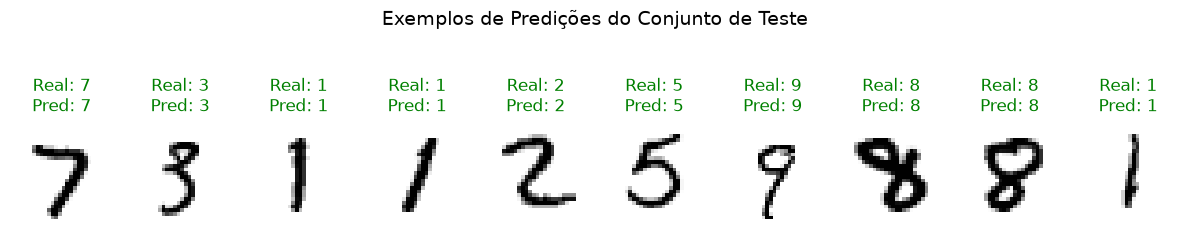

In [10]:
print("\nPodemos printar o report pra entender como o modelo performou na classificação dos digitos de (0 a 9)")
print(classification_report(y_test, y_pred))

# Visualizando 5 previsões
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i].reshape(28, 28), cmap='binary')
    ax.set_title(f"Real: {y_test[i]}\nPred: {y_pred[i]}", 
                 color='green' if y_test[i] == y_pred[i] else 'red')
    ax.axis('off')

plt.suptitle("Exemplos de Predições do Conjunto de Teste", fontsize=14)
plt.tight_layout()
plt.show()